# Code to compute node degree, common neighbour bias and gini coefficient for connectivity matrices

In [1]:
# loading usefull packages and functions

import numpy as np
import h5py
from matplotlib import pyplot as plt
import scipy.sparse as sp
import pandas as pd

from connalysis.network import classic as nxc
from connalysis.network import topology as nxt
from connalysis import randomization
from connalysis.network import topology
#from conntility import circuit_model
import conntility as conn
#from conntility import ConnectivityMatrix

#### Load all conn matrices to be used in the analysis

In [2]:
def load_conn_mat(conn_mat_path, conn_mat_to_file_name, group_name = None):
    root = conn_mat_path
    if group_name == None:
        conn_mat = conn.ConnectivityMatrix.from_h5(f"{root}{conn_mat_to_file_name}")
        out_put_conn_mat = conn_mat.matrix #.astype(bool).tocsr()
    elif group_name == "instance1":
        conn_mat = conn.ConnectivityMatrix.from_h5(f"{root}{conn_mat_to_file_name}", group_name="instance1")
        out_put_conn_mat = conn_mat.matrix #.astype(bool).tocsr()
    return out_put_conn_mat 

In [3]:
conn_mat_path = "/Users/natalibarroszulaica/Desktop/OBI/HUMAN_CORTEX/PAPERS_ON_GOING/CONNECTIVITY_PAPER/code/conn_matrix/"

# HUMAN
adj_human_st = load_conn_mat(conn_mat_path, "Human_NEWstruct_conmat_filtered_compressed.h5")
adj_human_fun = load_conn_mat(conn_mat_path, "Human_NEWfunct_conmat_filtered_compressed.h5")
adj_human_T_to_E = load_conn_mat(conn_mat_path, "Human_pruned_T_to_E_conmat.h5")
adj_human_E_to_E = load_conn_mat(conn_mat_path, "Human_pruned_E_to_E_conmat.h5")
#adj_human_T_to_T = load_conn_mat(conn_mat_path, "Human_pruned_T_to_T_conmat.h5")
#adj_human_E_to_T = load_conn_mat(conn_mat_path, "Human_pruned_E_to_T_conmat.h5")

# CONTROL
adj_human_control = load_conn_mat(conn_mat_path, "third_order_mdl_instances_humanized_rat.h5", "instance1")
adj_human_control_T_to_E = load_conn_mat(conn_mat_path, "humanized_rat_pruned_T_to_E_conmat.h5")
adj_human_control_E_to_E = load_conn_mat(conn_mat_path, "humanized_rat_pruned_E_to_E_conmat.h5")
#adj_human_control_E_to_T = load_conn_mat(conn_mat_path, "humanized_rat_pruned_E_to_T_conmat.h5")
#adj_human_control_T_to_T = load_conn_mat(conn_mat_path, "humanized_rat_pruned_T_to_T_conmat.h5")

# RAT
adj_rat_st = load_conn_mat(conn_mat_path, "Rat_623um_squared_struc_conmat_filtered_compressed.h5")
adj_rat_fun = load_conn_mat(conn_mat_path, "Rat_623um_squared_funct_conmat_filtered_compressed.h5")
adj_rat_T_to_E = load_conn_mat(conn_mat_path, "Rat_pruned_T_to_E_conmat.h5")
adj_rat_E_to_E = load_conn_mat(conn_mat_path, "Rat_pruned_E_to_E_conmat.h5")
#adj_rat_T_to_T = load_conn_mat(conn_mat_path, "Rat_pruned_T_to_T_conmat.h5")
#adj_rat_E_to_T = load_conn_mat(conn_mat_path, "Rat_pruned_E_to_T_conmat.h5")

### Node degree

In [4]:
# HUMAN
nd_human_st = topology.node_degree(adj_human_st, direction=('IN', 'OUT'))
nd_human_fun = topology.node_degree(adj_human_fun, direction=('IN', 'OUT'))
nd_human_T_to_E = topology.node_degree(adj_human_T_to_E, direction=('IN', 'OUT'))
nd_human_E_to_E = topology.node_degree(adj_human_E_to_E, direction=('IN', 'OUT'))
#nd_human_E_to_T = topology.node_degree(adj_human_E_to_T, direction=('IN', 'OUT'))
#nd_human_T_to_T = topology.node_degree(adj_human_T_to_T, direction=('IN', 'OUT'))

# CONTROL
nd_human_control = topology.node_degree(adj_human_control, direction=('IN', 'OUT'))
nd_human_control_T_to_E = topology.node_degree(adj_human_control_T_to_E, direction=('IN', 'OUT'))
nd_human_control_E_to_E = topology.node_degree(adj_human_control_E_to_E, direction=('IN', 'OUT'))
#nd_human_control_E_to_T = topology.node_degree(adj_human_control_E_to_T, direction=('IN', 'OUT'))
#nd_human_control_T_to_T = topology.node_degree(adj_human_control_T_to_T, direction=('IN', 'OUT'))

# RAT
nd_rat_st = topology.node_degree(adj_rat_st, direction=('IN', 'OUT'))
nd_rat_fun = topology.node_degree(adj_rat_fun, direction=('IN', 'OUT'))
nd_rat_E_to_E = topology.node_degree(adj_rat_E_to_E, direction=('IN', 'OUT'))
nd_rat_T_to_E = topology.node_degree(adj_rat_T_to_E, direction=('IN', 'OUT'))
#nd_rat_T_to_T = topology.node_degree(adj_rat_T_to_T, direction=('IN', 'OUT'))
#nd_rat_E_to_T = topology.node_degree(adj_rat_E_to_T, direction=('IN', 'OUT'))

#### Plot node degree

In [5]:
def plot_node_degree(nd_human, nd_rat, degree_direction, name, hight, nd_control=pd.DataFrame()):
    # nd_human: node degree computation for human con mat
    # nd_rat: node degree computation for human con mat
    # degree_direction: string; IN or OUT
    # name: string with name, preferably name defining matrix type (structural, functional, ...)
    # hight: float; y axes upper value
    # nd_control: node degree computation for human control. It doesn't exist for functional case.

    fig, ax0 = plt.subplots(figsize=(8, 6))
    ax0.set_title('%s %s: human %s, rat %s' %(name, degree_direction, np.mean(nd_human), np.mean(nd_rat)))
    if degree_direction == "IN":
        if not nd_control.empty:
            ax0.hist(nd_human.IN, 30, density=True, alpha=0.5, color='teal', label='human')
            ax0.hist(nd_rat.IN, 30, density=True, alpha=0.5, color='blueviolet', label='rat')
            ax0.hist(nd_control.IN, 30, density=True, histtype='step', fill=False, linestyle='dashed', linewidth=2, color='black', label='HC_RD')
            ax0.axvline(np.mean(nd_human.IN), color='teal', linestyle='dashed', linewidth=2)
            ax0.axvline(np.mean(nd_rat.IN), color='blueviolet', linestyle='dashed', linewidth=2)
        else:
            ax0.hist(nd_human.IN, 30, density=True, alpha=0.5, color='teal', label='human')
            ax0.hist(nd_rat.IN, 30, density=True, alpha=0.5, color='blueviolet', label='rat')
            ax0.axvline(np.mean(nd_human.IN), color='teal', linestyle='dashed', linewidth=2)
            ax0.axvline(np.mean(nd_rat.IN), color='blueviolet', linestyle='dashed', linewidth=2)
    elif degree_direction == "OUT":
       if not nd_control.empty:
            ax0.hist(nd_human.OUT, 30, density=True, alpha=0.5, color='teal', label='human')
            ax0.hist(nd_rat.OUT, 30, density=True, alpha=0.5, color='blueviolet', label='rat')
            ax0.hist(nd_control.OUT, 30, density=True, histtype='step', fill=False, linestyle='dashed', linewidth=2, color='black', label='HC_RD')
            ax0.axvline(np.mean(nd_human.OUT), color='teal', linestyle='dashed', linewidth=2)
            ax0.axvline(np.mean(nd_rat.OUT), color='blueviolet', linestyle='dashed', linewidth=2)
       else:
            ax0.hist(nd_human.OUT, 30, density=True, alpha=0.5, color='teal', label='human')
            ax0.hist(nd_rat.OUT, 30, density=True, alpha=0.5, color='blueviolet', label='rat')
            ax0.axvline(np.mean(nd_human.OUT), color='teal', linestyle='dashed', linewidth=2)
            ax0.axvline(np.mean(nd_rat.OUT), color='blueviolet', linestyle='dashed', linewidth=2)
    ax0.tick_params(axis='x', labelsize=15)
    ax0.tick_params(axis='y', labelsize=15)
    ax0.set_ylim(0, hight)
    ax0.set_xlabel('Node degree', fontsize=15)
    ax0.set_ylabel('Density', fontsize=15)
    ax0.spines[['right', 'top']].set_visible(False)
    plt.savefig('Conn_figures/%s_degree_%s_matrices.svg' %(degree_direction, name), transparent=True, bbox_inches='tight')
    plt.show()

#### Structural

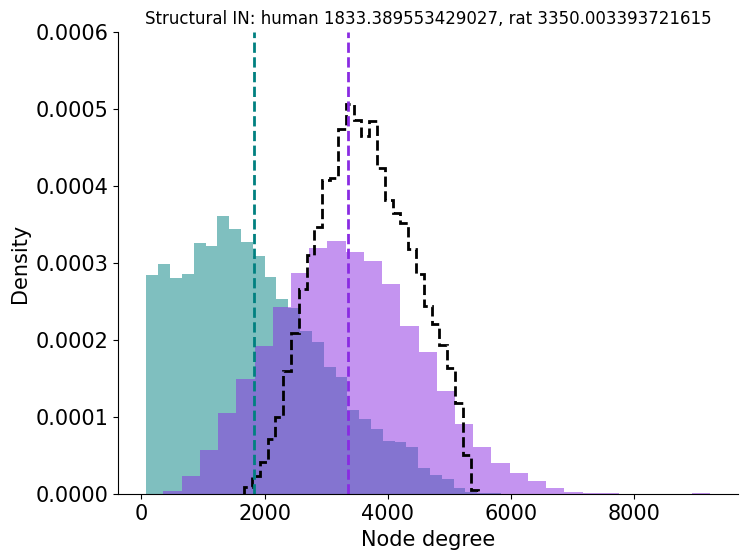

In [6]:
plot_node_degree(nd_human_st, nd_rat_st, "IN", "Structural", 0.0006, nd_human_control)

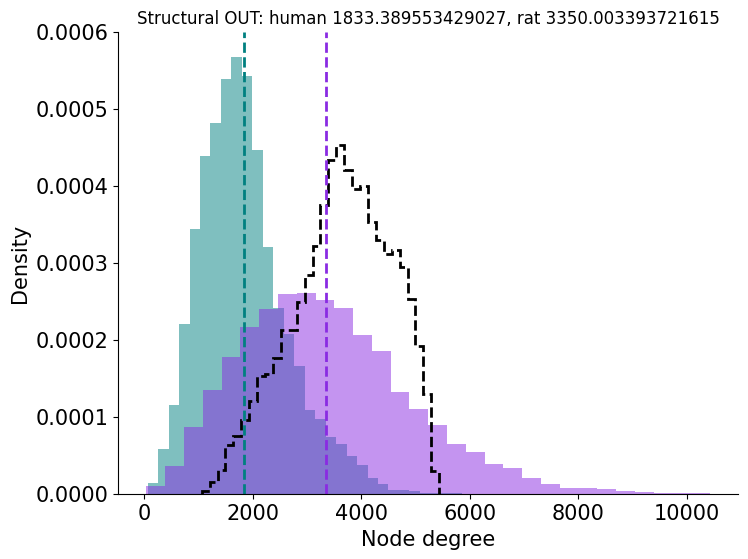

In [7]:
plot_node_degree(nd_human_st, nd_rat_st, "OUT", "Structural", 0.0006, nd_human_control)

#### Functional

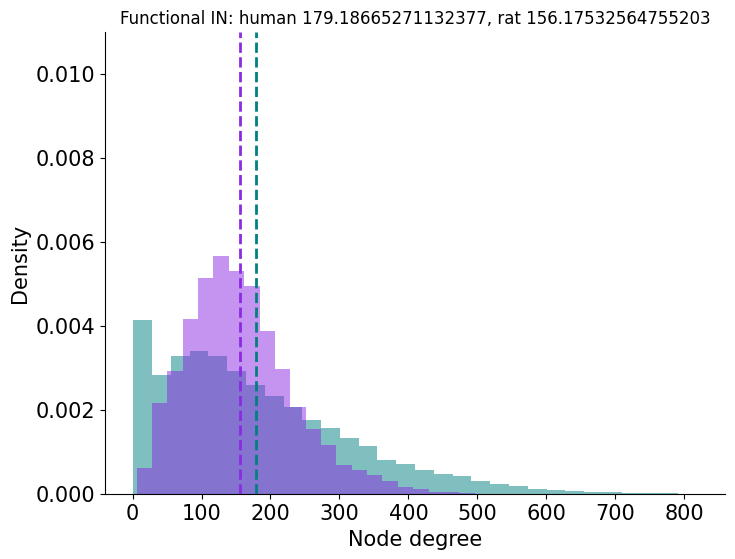

In [8]:
plot_node_degree(nd_human_fun, nd_rat_fun, "IN", "Functional", 0.011)

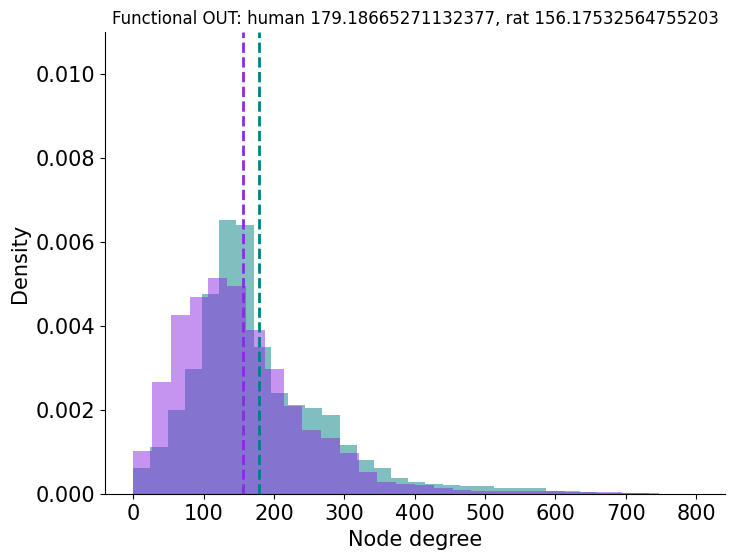

In [9]:
plot_node_degree(nd_human_fun, nd_rat_fun, "OUT", "Functional", 0.011)

#### Pruning touches to match edges

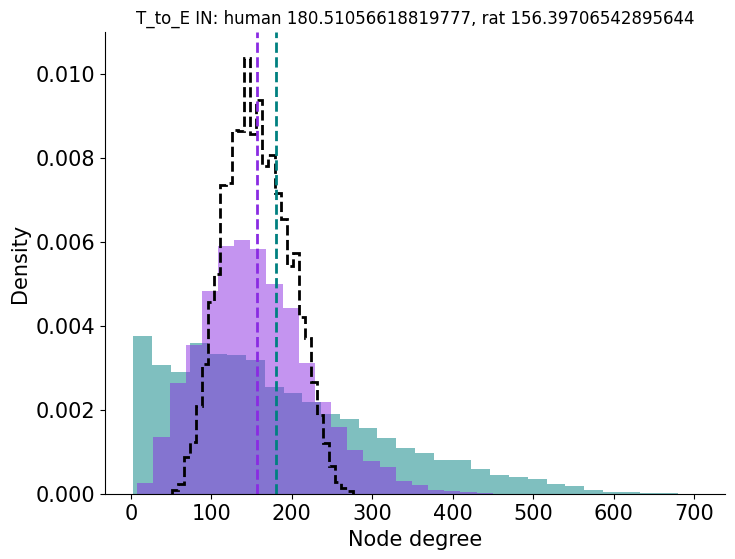

In [10]:
plot_node_degree(nd_human_T_to_E, nd_rat_T_to_E, "IN", "T_to_E", 0.011, nd_human_control_T_to_E)

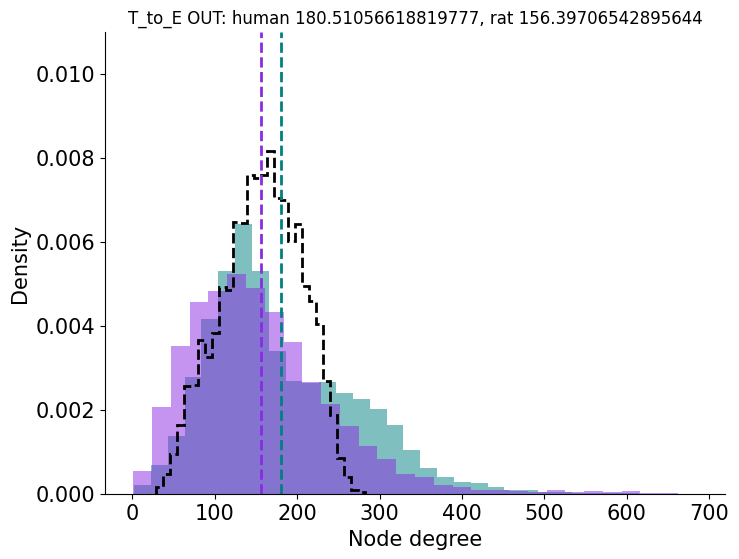

In [11]:
plot_node_degree(nd_human_T_to_E, nd_rat_T_to_E, "OUT", "T_to_E", 0.011, nd_human_control_T_to_E)

#### Pruning Edges to match Edges

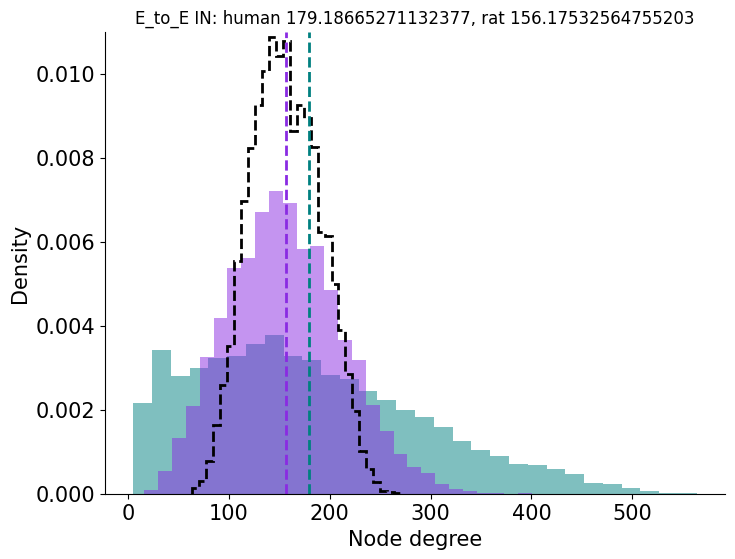

In [12]:
plot_node_degree(nd_human_E_to_E, nd_rat_E_to_E, "IN", "E_to_E", 0.011, nd_human_control_E_to_E)

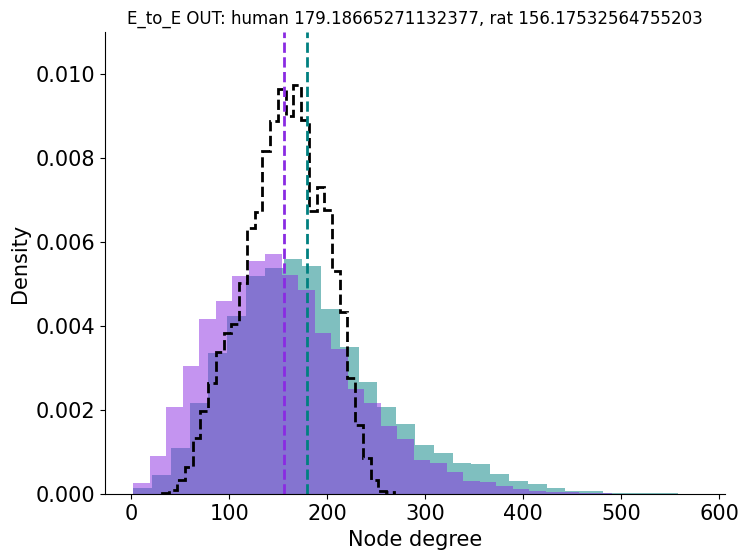

In [13]:
plot_node_degree(nd_human_E_to_E, nd_rat_E_to_E, "OUT", "E_to_E", 0.011, nd_human_control_E_to_E)

### Node degree skew

In [19]:
# degree skew: measurement of distribution tail
import scipy

# IN
sk_human_fun_in = scipy.stats.skew(nd_human_fun.IN)
sk_human_T_to_E_in = scipy.stats.skew(nd_human_T_to_E.IN)
sk_human_E_to_E_in = scipy.stats.skew(nd_human_E_to_E.IN)

sk_control_T_to_E_in = scipy.stats.skew(nd_human_control_T_to_E.IN)
sk_control_E_to_E_in = scipy.stats.skew(nd_human_control_E_to_E.IN)

sk_rat_fun_in = scipy.stats.skew(nd_rat_fun.IN)
sk_rat_T_to_E_in = scipy.stats.skew(nd_rat_T_to_E.IN)
sk_rat_E_to_E_in = scipy.stats.skew(nd_rat_E_to_E.IN)

In [20]:
# OUT
sk_human_fun_out = scipy.stats.skew(nd_human_fun.OUT)
sk_human_T_to_E_out = scipy.stats.skew(nd_human_T_to_E.OUT)
sk_human_E_to_E_out = scipy.stats.skew(nd_human_E_to_E.OUT)

sk_control_T_to_E_out = scipy.stats.skew(nd_human_control_T_to_E.OUT)
sk_control_E_to_E_out = scipy.stats.skew(nd_human_control_E_to_E.OUT)

sk_rat_fun_out = scipy.stats.skew(nd_rat_fun.OUT)
sk_rat_T_to_E_out = scipy.stats.skew(nd_rat_T_to_E.OUT)
sk_rat_E_to_E_out = scipy.stats.skew(nd_rat_E_to_E.OUT)

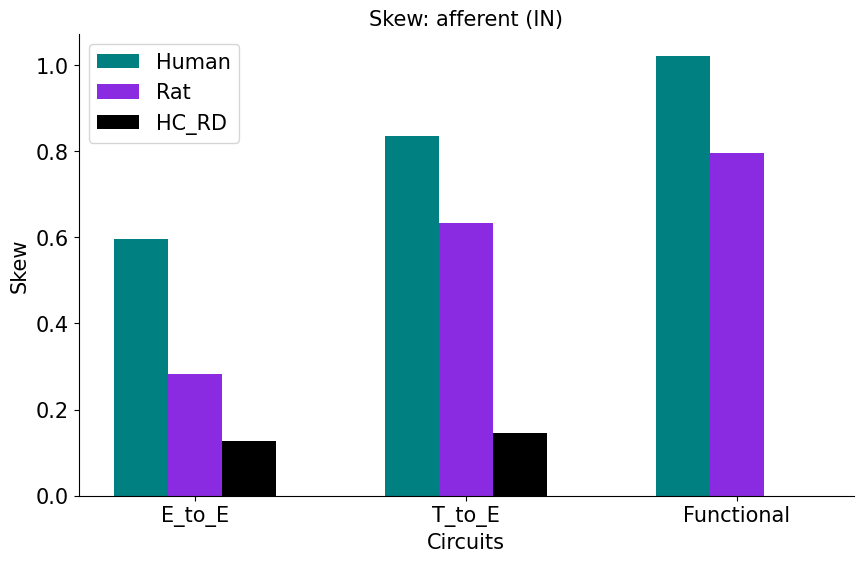

In [21]:
circuits = ("E_to_E", "T_to_E", "Functional")

sk_human = [sk_human_E_to_E_in, sk_human_T_to_E_in, sk_human_fun_in]
sk_rat = [sk_rat_E_to_E_in, sk_rat_T_to_E_in, sk_rat_fun_in]
sk_control = [sk_control_E_to_E_in, sk_control_T_to_E_in, 0.0]

dis = [0, 5, 10]

barwidth = 2
br1 = [x - barwidth/2 for x in dis] 
br2 = [x for x in dis] 
br3 = [x + barwidth/2 for x in dis] 

plt.figure(figsize=(10, 6))
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.title('Skew: afferent (IN)', fontsize=15)
plt.bar(br1, sk_human, color='teal', width=1, label='Human')
plt.bar(br2, sk_rat, color='blueviolet', width=1, label='Rat')
plt.bar(br3, sk_control, color='black', width=1, label='HC_RD')
plt.ylabel('Skew', fontsize=15)
plt.xlabel('Circuits', fontsize=15)
plt.xticks(dis, circuits, fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=15)


plt.savefig('Conn_figures/skew_IN.svg',transparent=True, bbox_inches='tight')

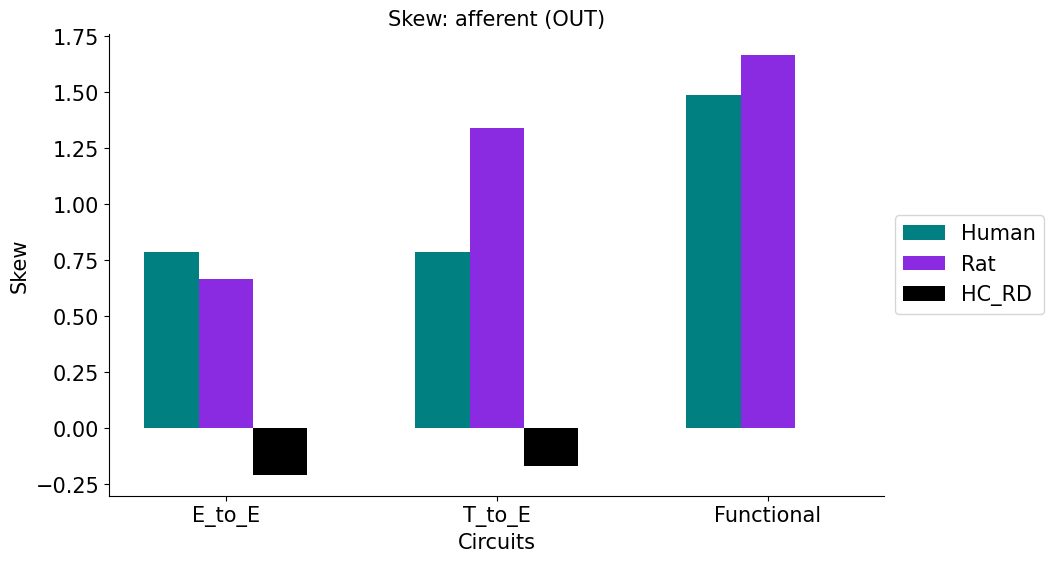

In [22]:
circuits = ("E_to_E", "T_to_E", "Functional")

sk_human = [sk_human_E_to_E_out, sk_human_T_to_E_out, sk_human_fun_out]
sk_rat = [sk_rat_E_to_E_out, sk_rat_T_to_E_out, sk_rat_fun_out]
sk_control = [sk_control_E_to_E_out, sk_control_T_to_E_out, 0.0]

dis = [0, 5, 10]

barwidth = 2
br1 = [x - barwidth/2 for x in dis] 
br2 = [x for x in dis] 
br3 = [x + barwidth/2 for x in dis] 

plt.figure(figsize=(10, 6))
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.title('Skew: afferent (OUT)', fontsize=15)
plt.bar(br1, sk_human, color='teal', width=1, label='Human')
plt.bar(br2, sk_rat, color='blueviolet', width=1, label='Rat')
plt.bar(br3, sk_control, color='black', width=1, label='HC_RD')
plt.ylabel('Skew', fontsize=15)
plt.xlabel('Circuits', fontsize=15)
plt.xticks(dis, circuits, fontsize=15)
plt.yticks(fontsize=15)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=15)


plt.savefig('Conn_figures/skew_OUT.svg',transparent=True, bbox_inches='tight')

### Common neighbour bias

In [44]:
def run_common_neighbor_connectivity_bias(conn_mat):
    conn_mat_afferent = nxc.common_neighbor_connectivity_bias(conn_mat, neuron_properties=None, direction='afferent', 
                                                  cols_location=None, fit_log=False)
    conn_mat_efferent = nxc.common_neighbor_connectivity_bias(conn_mat, neuron_properties=None, direction='efferent', 
                                                  cols_location=None, fit_log=False)
    conn_mat_CNB = (conn_mat_afferent[1], conn_mat_efferent[1])
    return conn_mat_CNB

In [45]:
cnb_h_st = run_common_neighbor_connectivity_bias(adj_human_st)

In [46]:
cnb_r_st = run_common_neighbor_connectivity_bias(adj_rat_st)

In [47]:
cnb_h_E_to_E = run_common_neighbor_connectivity_bias(adj_human_E_to_E)

In [48]:
cnb_r_E_to_E = run_common_neighbor_connectivity_bias(adj_rat_E_to_E)

In [49]:
cnb_h_T_to_E = run_common_neighbor_connectivity_bias(adj_human_T_to_E)

In [50]:
cnb_r_T_to_E = run_common_neighbor_connectivity_bias(adj_rat_T_to_E)

In [52]:
cnb_h_fun = run_common_neighbor_connectivity_bias(adj_human_fun)

In [53]:
cnb_r_fun = run_common_neighbor_connectivity_bias(adj_rat_fun)

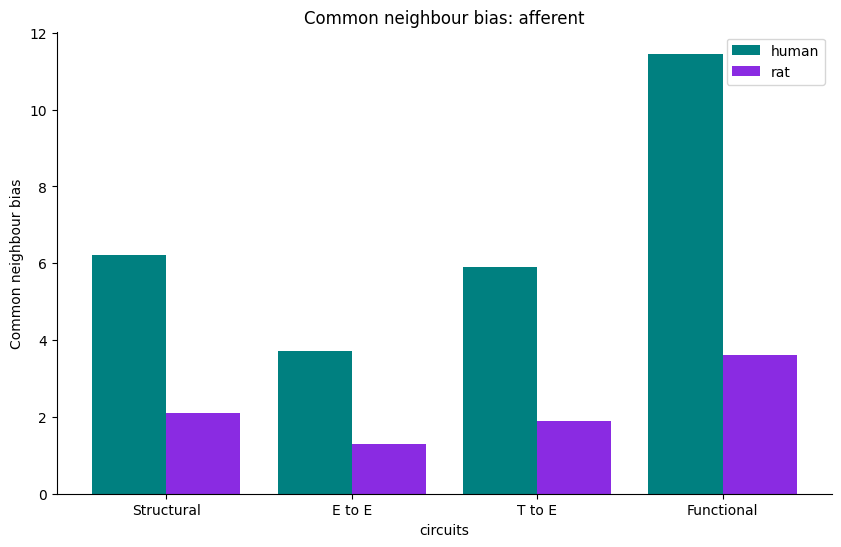

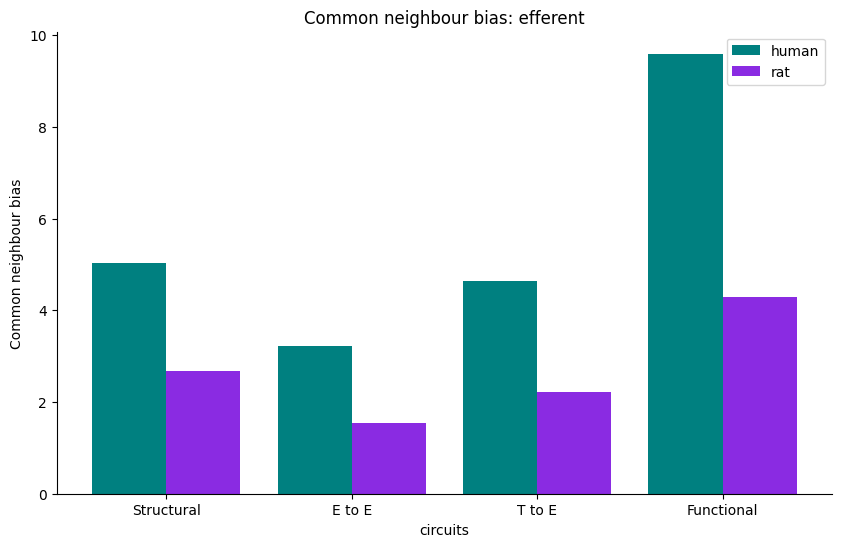

In [54]:
circuits = ("Structural", "E to E", "T to E", "Functional")

# afferent
cnb_human_aff = [cnb_h_st[0], cnb_h_E_to_E[0], cnb_h_T_to_E[0], cnb_h_fun[0]]
cnb_rat_aff = [cnb_r_st[0], cnb_r_E_to_E[0], cnb_r_T_to_E[0], cnb_r_fun[0]]

# efferent
cnb_human_eff = [cnb_h_st[1], cnb_h_E_to_E[1], cnb_h_T_to_E[1], cnb_h_fun[1]]
cnb_rat_eff = [cnb_r_st[1], cnb_r_E_to_E[1], cnb_r_T_to_E[1], cnb_r_fun[1]]

dis = [0, 5, 10, 15]

barwidth = 2
br1 = [x - barwidth/2 for x in dis] 
br2 = [x + barwidth/2 for x in dis]  

# Plot afferent
plt.figure(figsize=(10, 6))
plt.title('Common neighbour bias: afferent')
plt.bar(br1, cnb_human_aff, color='teal', width=2, label='human')
plt.bar(br2, cnb_rat_aff, color='blueviolet', width=2, label='rat')
plt.ylabel('Common neighbour bias')
plt.xlabel('circuits')
plt.xticks(dis, circuits)
plt.legend()
plt.savefig('Conn_figures/CommonNeigh_afferent.svg',transparent=True, bbox_inches='tight')

# Plot efferent
plt.figure(figsize=(10, 6))
plt.title('Common neighbour bias: efferent')
plt.bar(br1, cnb_human_eff, color='teal', width=2, label='human')
plt.bar(br2, cnb_rat_eff, color='blueviolet', width=2, label='rat')
plt.ylabel('Common neighbour bias')
plt.xlabel('circuits')
plt.xticks(dis, circuits)
plt.legend()
plt.savefig('Conn_figures/CommonNeigh_efferent.svg',transparent=True, bbox_inches='tight')

#### Gini coefficient

In [57]:
def run_gini_coeff(conn_mat):
    gc_aff = nxc.gini_coefficient(conn_mat, nrn=None, direction='afferent')
    gc_eff = nxc.gini_coefficient(conn_mat, nrn=None, direction='efferent')
    return [gc_aff, gc_eff]

In [58]:
gc_h_st = run_gini_coeff(adj_human_st)
gc_r_st = run_gini_coeff(adj_rat_st)

gc_h_E_to_E = run_gini_coeff(adj_human_E_to_E)
gc_r_E_to_E = run_gini_coeff(adj_rat_E_to_E)

gc_h_T_to_E = run_gini_coeff(adj_human_T_to_E)
gc_r_T_to_E = run_gini_coeff(adj_rat_T_to_E)

gc_h_fun = run_gini_coeff(adj_human_fun)
gc_r_fun = run_gini_coeff(adj_rat_fun)

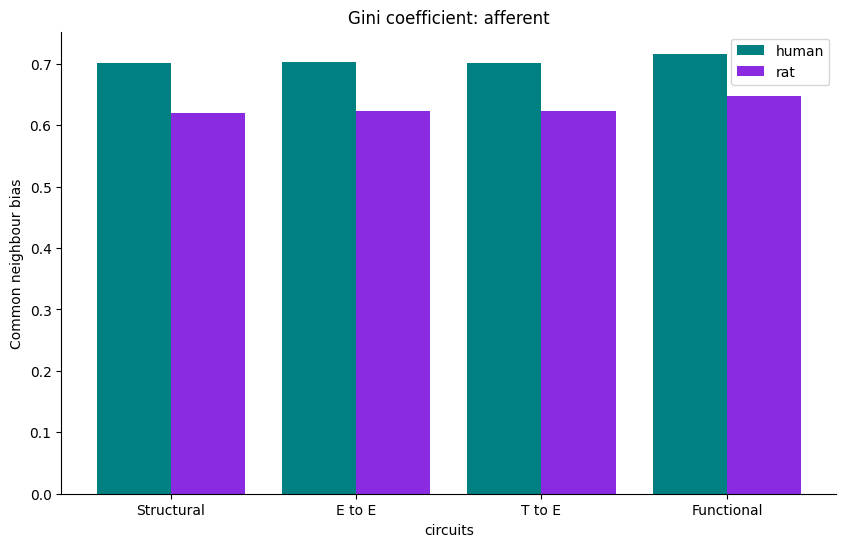

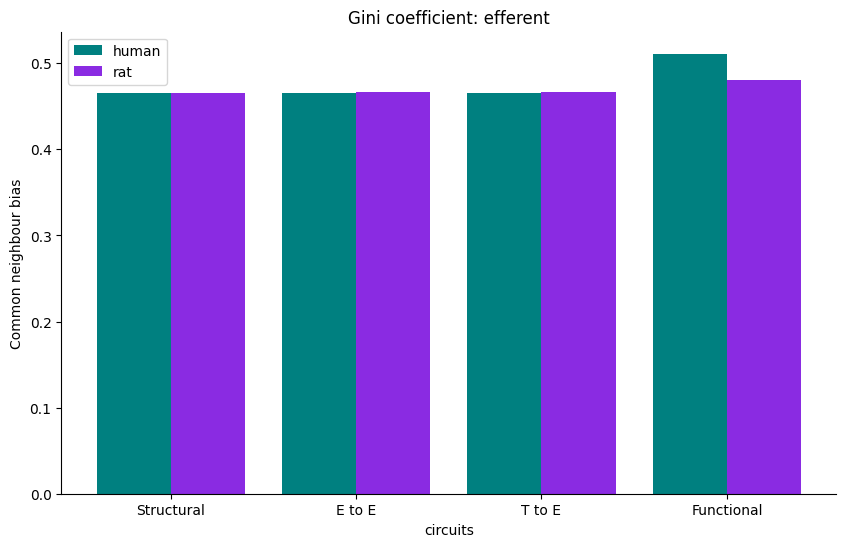

In [59]:
# afferent
gc_human_aff = [gc_h_st[0], gc_h_E_to_E[0], gc_h_T_to_E[0], gc_h_fun[0]]
gc_rat_aff = [gc_r_st[0], gc_r_E_to_E[0], gc_r_T_to_E[0], gc_r_fun[0]]

# efferent
gc_human_eff = [gc_h_st[1], gc_h_E_to_E[1], gc_h_T_to_E[1], gc_h_fun[1]]
gc_rat_eff = [gc_r_st[1], gc_r_E_to_E[1], gc_r_T_to_E[1], gc_r_fun[1]]

barwidth = 2
br1 = [x - barwidth/2 for x in dis] 
br2 = [x + barwidth/2 for x in dis]  

# Plot afferent
plt.figure(figsize=(10, 6))
plt.title('Gini coefficient: afferent')
plt.bar(br1, gc_human_aff, color='teal', width=2, label='human')
plt.bar(br2, gc_rat_aff, color='blueviolet', width=2, label='rat')
plt.ylabel('Common neighbour bias')
plt.xlabel('circuits')
plt.xticks(dis, circuits)
plt.legend()
plt.savefig('Conn_figures/GiniCoeff_afferent.svg',transparent=True, bbox_inches='tight')

# Plot efferent
plt.figure(figsize=(10, 6))
plt.title('Gini coefficient: efferent')
plt.bar(br1, gc_human_eff, color='teal', width=2, label='human')
plt.bar(br2, gc_rat_eff, color='blueviolet', width=2, label='rat')
plt.ylabel('Common neighbour bias')
plt.xlabel('circuits')
plt.xticks(dis, circuits)
plt.legend()
plt.savefig('Conn_figures/GiniCoeff_efferent.svg',transparent=True, bbox_inches='tight')